# Module 1: Bernoulli and Poisson Processes

In many situations, we want to count random events over time. For example, packets may arrive at a communication channel, customers may enter a queue, or calls may arrive at a phone line.

We first study a discrete time model, where time is divided into slots. Then we study a continuous-time model, where events can occur at any time.

## Libraries

Run the cell below to import the libraries used in this module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

In [2]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Example 1: Bernoulli arrivals in time slots

We model packet arrivals in discrete time. Time is divided into slots, and in each slot either one packet arrives or no packet arrives. Let

$$
X_k =
\begin{cases}
1, & 	\text{if a packet arrives in slot } k,\\
0, & 	\text{otherwise.}
\end{cases}
$$

The probability of an arrival in each slot is

$$
P(X_k=1)=p.
$$

In [3]:
# Number of time slots
n_slots = 100

# Probability of an event in one slot
p = 0.3

# Create a random generator
rng = np.random.default_rng()

# Simulate events in the slots
X = rng.binomial(1, p, size=n_slots)

print(X)

[1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0
 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1]


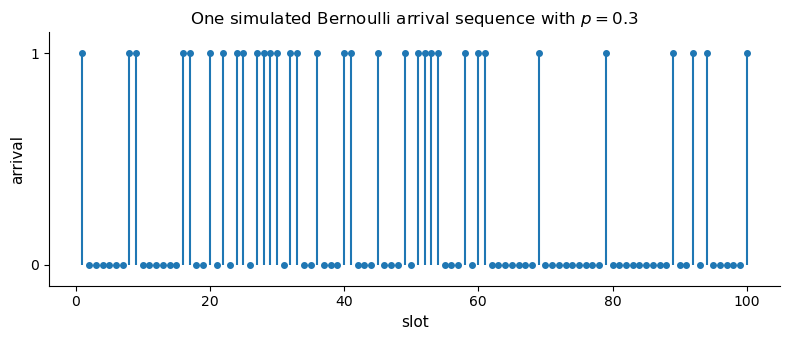

In [4]:
# Plot the simulated arrivals
plt.figure(figsize=SMALL_FIGSIZE)

plt.stem(np.arange(1, n_slots + 1), X, basefmt=" ")

plt.xlabel("slot")
plt.ylabel("arrival")
plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.title(f"One simulated Bernoulli arrival sequence with $p={p}$")
plt.tight_layout()
plt.show()

The plot shows one simulated Bernoulli arrival sequence. Each vertical mark means that an event occurs in that slot. The total number of events up to slot $n$ is

$$
S_n = \sum_{k=1}^{n} X_k.
$$

Thus, $S_n$ is the accumulated event count.

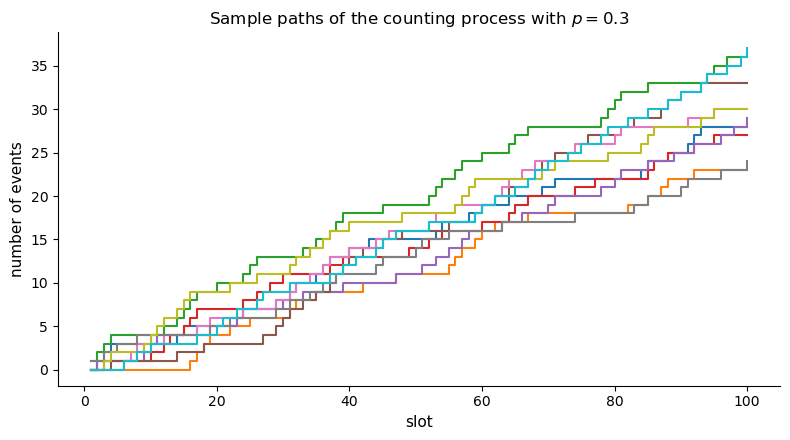

In [5]:
# Number of sample paths
n_paths = 10

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for path in range(n_paths):
    X = rng.binomial(1, p, size=n_slots)
    S = np.cumsum(X)
    plt.step(np.arange(1, n_slots + 1), S, where="post")

plt.xlabel("slot")
plt.ylabel("number of events")
plt.title(f"Sample paths of the counting process with $p={p}$")
plt.tight_layout()
plt.show()

Each curve is one simulated path of the counting process $S_n$. The paths only stay the same or increase, because each new slot can add either $0$ or $1$ event.

## Example 2: Distribution of the total number of events

In one simulation, $S_n$ gives the number of events in $n$ slots.

Since each slot has event probability $p$, and the slots are independent, $S_n$ has the binomial distribution

$$
S_n \sim \mathrm{Bin}(n,p).
$$

If we repeat the same experiment $m$ times, we obtain a random sample of size $m$ from this binomial distribution.

In [6]:
# Number of slots in one experiment
n = 100

# Probability of an event in one slot
p = 0.3

# Number of repeated experiments
m = 10000

# Create a random generator
rng = np.random.default_rng()

# Simulate the total number of events in each experiment
S_values = rng.binomial(n, p, size=m)

print("First 10 simulated values:")
print(S_values[:10])

First 10 simulated values:
[30 36 26 26 30 27 40 27 27 29]


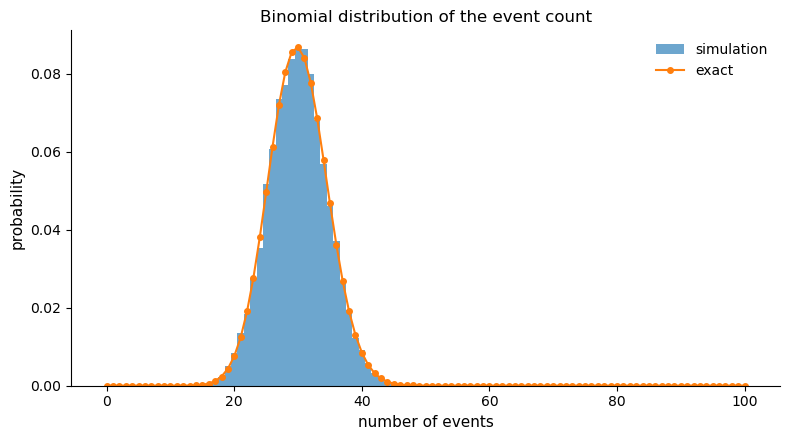

In [7]:
# Possible values of S_n
k_values = np.arange(0, n + 1)

# Exact binomial probabilities
p_exact = binom.pmf(k_values, n, p)

plt.figure(figsize=FIGSIZE)

plt.hist(
    S_values,
    bins=np.arange(-0.5, n + 1.5, 1),
    density=True,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(k_values, p_exact, "o-", label="exact")

plt.xlabel("number of events")
plt.ylabel("probability")
plt.title("Binomial distribution of the event count")
plt.legend()
plt.tight_layout()
plt.show()

The histogram is based on many repeated simulations. In each simulation, the final value of $S_n$ is recorded. The points show the binomial probabilities

$$
P(S_n = k) = \binom{n}{k}p^k(1-p)^{n-k}.
$$

### Task 1

Change the event probability $p$ and run the simulation again. Try

$$
p = 0.1,\quad 0.3,\quad 0.6.
$$

Describe how the distribution of $S_n$ changes.

In [8]:
# Change p in the previous simulation, or copy the code here and try new values.
# Suggested values: 0.1, 0.3, 0.6.

### Example solution

The exact distribution is still binomial. The parameter $p$ changes where the distribution is centred.

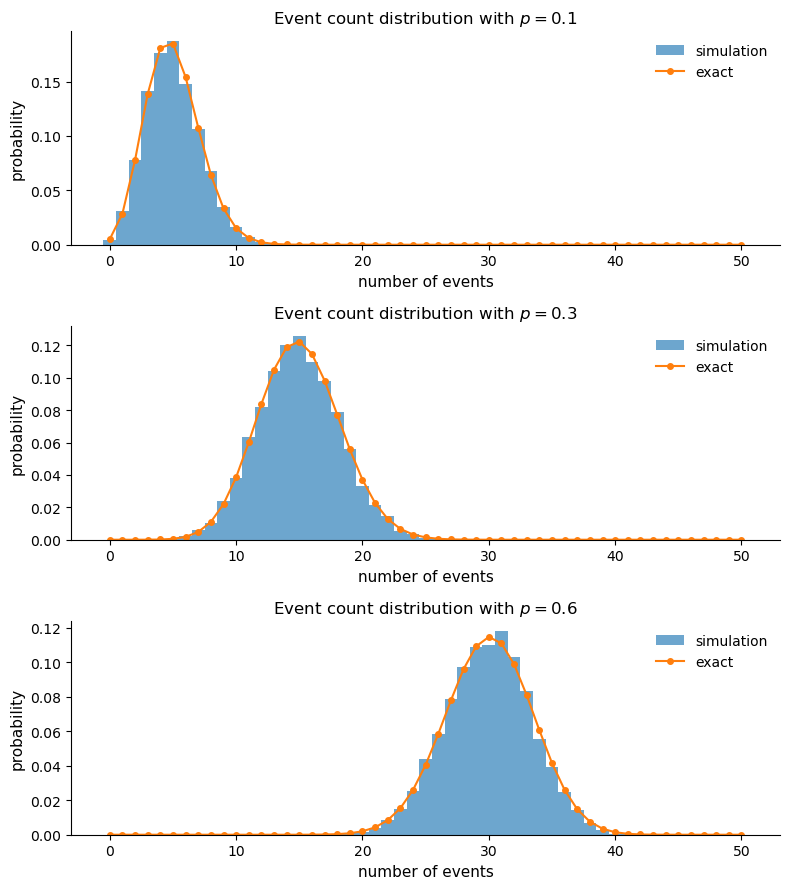

In [9]:
# Compare different event probabilities
p_values = [0.1, 0.3, 0.6]

# Number of slots in one experiment
n = 50

# Number of repeated experiments
N = 10000

# Create a random generator
rng = np.random.default_rng()

fig, axes = plt.subplots(3, 1, figsize=SUBPLOT_FIGSIZE)

for i, p in enumerate(p_values):
    S_values = rng.binomial(n, p, size=N)

    k_values = np.arange(0, n + 1)
    p_exact = binom.pmf(k_values, n, p)

    axes[i].hist(
        S_values,
        bins=np.arange(-0.5, n + 1.5, 1),
        density=True,
        alpha=HIST_ALPHA,
        label="simulation"
    )

    axes[i].plot(k_values, p_exact, "o-", label="exact")

    axes[i].set_xlabel("number of events")
    axes[i].set_ylabel("probability")
    axes[i].set_title(f"Event count distribution with $p={p}$")
    axes[i].legend()

plt.tight_layout()
plt.show()

Changing $p$ changes the distribution of $S_n$. When $p$ is larger, the distribution moves to the right because more events are expected.

## Example 3: Waiting time until the first event

Now we study the waiting time until the first event occurs. Let

$$
Y = \text{number of slots until the first event}.
$$

The random variable $Y$ has the positive geometric distribution. If the first event occurs in slot $k$, then the first $k-1$ slots have no event, and slot $k$ has an event. Therefore,

$$
P(Y=k) = (1-p)^{k-1}p, \quad k=1,2,3,\ldots
$$

The positive geometric distribution has the memoryless property:

$$
P(Y-n=k \mid Y>n)=P(Y=k), \quad k=1,2,\ldots
$$

This means that after a stretch of empty slots, the Bernoulli process starts afresh.

In [10]:
# Probability of an event in one slot
p = 0.3

# Create a random generator
rng = np.random.default_rng()

# Simulate the waiting time until the first event
Y = rng.geometric(p)

print("Waiting time Y =", Y)

Waiting time Y = 3


In [11]:
# Probability of an event in one slot
p = 0.3

# Number of repeated experiments
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Simulate many waiting times
Y_values = rng.geometric(p, size=N)

print("First 10 waiting times:")
print(Y_values[:10])

First 10 waiting times:
[8 1 1 3 2 5 2 1 4 3]


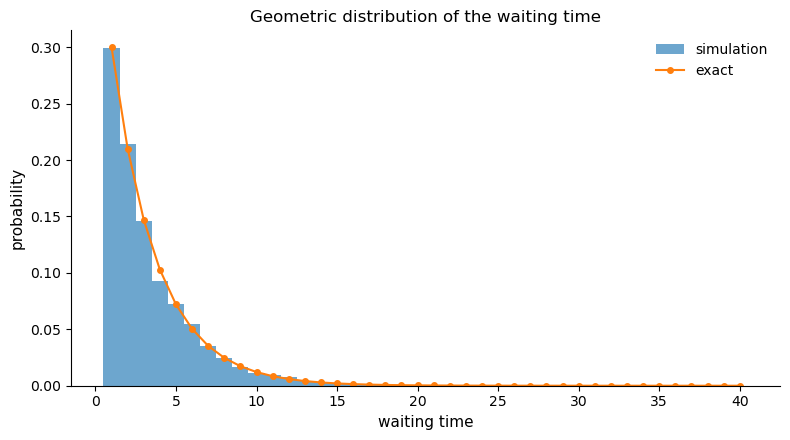

In [12]:
# Values to show in the plot
max_k = 40
k_values = np.arange(1, max_k + 1)

# Exact probabilities
p_exact = (1 - p) ** (k_values - 1) * p

plt.figure(figsize=FIGSIZE)

plt.hist(
    Y_values,
    bins=np.arange(0.5, max_k + 1.5, 1),
    density=True,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(k_values, p_exact, "o-", label="exact")

plt.xlabel("waiting time")
plt.ylabel("probability")
plt.title("Geometric distribution of the waiting time")
plt.legend()
plt.tight_layout()
plt.show()

The bars show simulated waiting times until the first event. The points show the geometric probabilities

$$
P(Y=k) = (1-p)^{k-1}p, \qquad k=1,2,\ldots.
$$

Early arrivals are more likely than very long waiting times.

To check the memoryless property by simulation, first simulate many waiting times $Y$. Then keep only the samples with $Y>n$ and compute the additional waiting time $Y-n$.

If the memoryless property holds, the conditional distribution of $Y-n$ given $Y>n$ should be close to the distribution of $Y$.

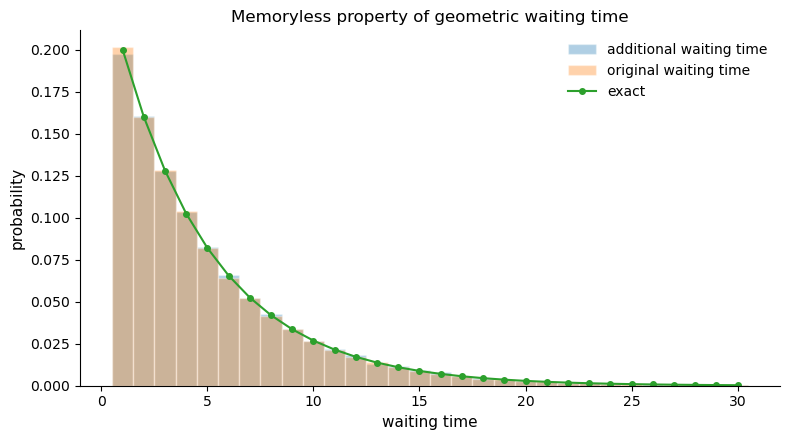

Mean of original waiting time: 4.99331
Mean of additional waiting time: 5.028569673138363
Theoretical mean: 5.0


In [13]:
# Simulation check: memoryless property

p = 0.2
N = 100000
n = 5

rng = np.random.default_rng()

# Simulate waiting times until the first event
Y = rng.geometric(p, size=N)

# Keep the cases where no event occurs in the first n slots
Y_after_n = Y[Y > n] - n

# Compare with the original waiting time distribution
max_k = 30
k_values = np.arange(1, max_k + 1)
p_exact = (1 - p) ** (k_values - 1) * p

plt.figure(figsize=FIGSIZE)

plt.hist(
    Y_after_n,
    bins=np.arange(0.5, max_k + 1.5, 1),
    density=True,
    alpha=0.35,
    edgecolor="white",
    label="additional waiting time"
)

plt.hist(
    Y,
    bins=np.arange(0.5, max_k + 1.5, 1),
    density=True,
    alpha=0.35,
    edgecolor="white",
    label="original waiting time"
)
plt.plot(k_values, p_exact, "o-", label="exact")

plt.xlabel("waiting time")
plt.ylabel("probability")
plt.title("Memoryless property of geometric waiting time")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean of original waiting time:", np.mean(Y))
print("Mean of additional waiting time:", np.mean(Y_after_n))
print("Theoretical mean:", 1 / p)

The two distributions are almost the same. The simulation illustrates the memoryless property:

$$
P(Y-n=k \mid Y>n) = P(Y=k), \qquad k=1,2,\ldots.
$$

After $n$ empty slots, the waiting time starts again in distribution.

### Task 2

Change the value of $p$ and run the simulation again. Try

$$
p = 0.1,\quad 0.3,\quad 0.6.
$$

Describe how the waiting time changes.

In [14]:
# Change p in the previous waiting time simulation, or copy the code here.
# Suggested values: 0.1, 0.3, 0.6.

### Example solution

The examples below compare geometric waiting time distributions for three values of $p$.

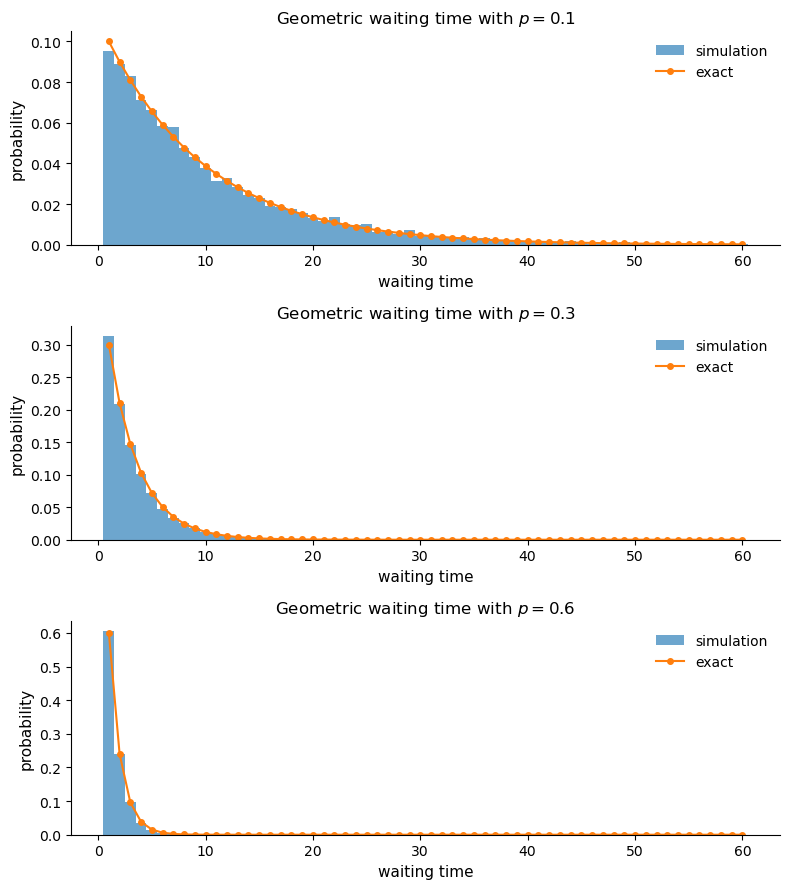

In [15]:
# Compare different event probabilities
p_values = [0.1, 0.3, 0.6]

# Number of repeated experiments
N = 10000

# Waiting time values to show
max_k = 60
k_values = np.arange(1, max_k + 1)

# Create a random generator
rng = np.random.default_rng()

fig, axes = plt.subplots(3, 1, figsize=SUBPLOT_FIGSIZE)

for i, p in enumerate(p_values):
    Y_values = rng.geometric(p, size=N)
    p_exact = (1 - p) ** (k_values - 1) * p

    axes[i].hist(
        Y_values,
        bins=np.arange(0.5, max_k + 1.5, 1),
        density=True,
        alpha=HIST_ALPHA,
        label="simulation"
    )

    axes[i].plot(k_values, p_exact, "o-", label="exact")

    axes[i].set_xlabel("waiting time")
    axes[i].set_ylabel("probability")
    axes[i].set_title(f"Geometric waiting time with $p={p}$")
    axes[i].legend()

plt.tight_layout()
plt.show()

When $p$ is larger, the first event is more likely to occur early. When $p$ is smaller, longer waiting times become more common.

## Example 4: From discrete time to continuous time

Now we make the time slots smaller. Fix a time interval $[0,t]$. Suppose one unit of time is divided into $n$ small slots, and the event probability in each small slot is

$$
p = \frac{\lambda}{n}.
$$

Here $\lfloor nt\rfloor$ denotes the integer part of $nt$. Then the number of events up to time $t$ has the binomial distribution

$$
S_{\lfloor nt\rfloor} \sim \mathrm{Bin}(\lfloor nt\rfloor, \lambda/n).
$$

When $n$ is large, this binomial distribution is close to a Poisson distribution with mean $\lambda t$:

$$
S_{\lfloor nt\rfloor} \approx \mathrm{Po}(\lambda t).
$$

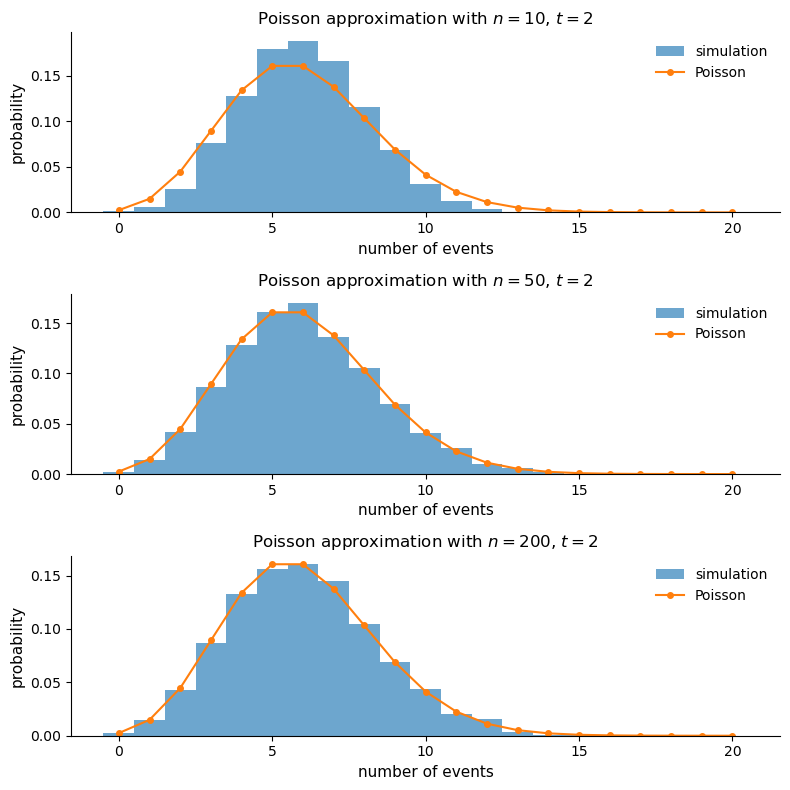

In [16]:
# Fixed time
t = 2

# Event rate per unit time
lam = 3

# Different numbers of slots per unit time
n_values = [10, 50, 200]

# Number of repeated experiments
N = 10000

# Maximum value to show
max_k = 20
k_values = np.arange(0, max_k + 1)

# Create a random generator
rng = np.random.default_rng()

fig, axes = plt.subplots(3, 1, figsize=(8, 8))

for i, n in enumerate(n_values):
    # Number of small slots up to time t
    m = int(n * t)

    # Event probability in one small slot
    p = lam / n

    # Simulate Bernoulli counts
    S_values = rng.binomial(m, p, size=N)

    # Poisson probabilities with mean lambda * t
    p_poisson = poisson.pmf(k_values, lam * t)

    axes[i].hist(
        S_values,
        bins=np.arange(-0.5, max_k + 1.5, 1),
        density=True,
        alpha=HIST_ALPHA,
        label="simulation"
    )

    axes[i].plot(k_values, p_poisson, "o-", label="Poisson")

    axes[i].set_xlabel("number of events")
    axes[i].set_ylabel("probability")
    axes[i].set_title(f"Poisson approximation with $n={n}$, $t={t}$")
    axes[i].legend()

plt.tight_layout()
plt.show()

Each histogram comes from repeated simulations of the Bernoulli count $S_{\lfloor nt\rfloor}$. The points show the Poisson probabilities with mean $\lambda t$. As $n$ increases,

$$
S_{\lfloor nt\rfloor} \sim \mathrm{Bin}(\lfloor nt\rfloor,\lambda/n)
$$

becomes close to

$$
\mathrm{Po}(\lambda t).
$$

## Example 5: Simulating a Poisson process

A Poisson process counts events in continuous time. The process is constructed from exponential waiting times. Let $U_1,U_2,\ldots$ be independent exponential waiting times with rate $\lambda$. The event times are

$$
T_1 = U_1,
$$

$$
T_2 = U_1 + U_2,
$$

and in general,

$$
T_k = U_1 + U_2 + \cdots + U_k.
$$

The counting process is

$$
N(t) = 	\text{number of event times } T_k 	\text{ such that } T_k \leq t.
$$

### Exponential waiting times

The waiting time between two consecutive events is continuous. If the rate is $\lambda$, then

$$
U \sim \mathrm{Exp}(\lambda).
$$

A larger value of $\lambda$ means shorter waiting times on average.

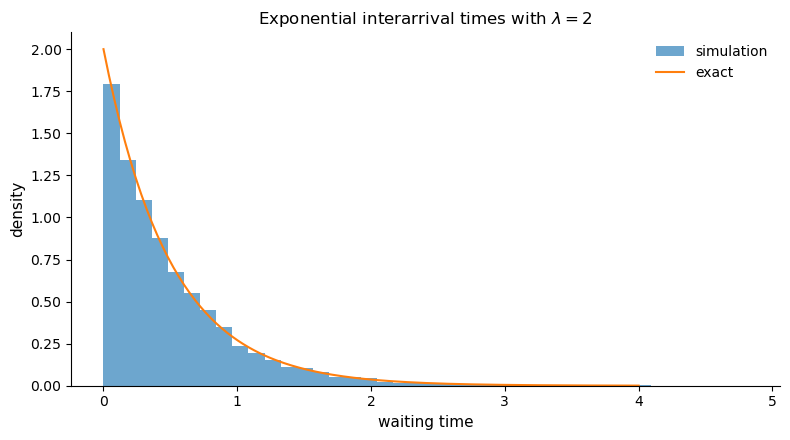

In [29]:
# Event rate
lam = 2

# Number of simulated waiting times
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Simulate exponential waiting times
U_values = rng.exponential(1 / lam, size=N)

# Values for the exact density
u_values = np.linspace(0, 4, 200)
density = lam * np.exp(-lam * u_values)

plt.figure(figsize=FIGSIZE)

plt.hist(
    U_values,
    bins=40,
    density=True,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(u_values, density, label="exact")

plt.xlabel("waiting time")
plt.ylabel("density")
plt.title(f"Exponential interarrival times with $\\lambda={lam}$")
plt.legend()
plt.tight_layout()
plt.show()

### Poisson process paths

We now use exponential waiting times to construct paths of the Poisson process. The process stays constant between event times and jumps up by one when a new event occurs. The jump times are

$$
T_k = U_1+\cdots+U_k.
$$

In [30]:
# Time horizon
T_max = 10

# Event rate
lam = 2

# Create a random generator
rng = np.random.default_rng()

# Simulate event times until the next event would be after T_max
event_times = []
current_time = 0

while current_time <= T_max:
    waiting_time = rng.exponential(1 / lam)
    current_time = current_time + waiting_time

    if current_time <= T_max:
        event_times.append(current_time)

event_times = np.array(event_times)

print("Number of events =", len(event_times))
print("Event times:")
print(event_times)

Number of events = 10
Event times:
[1.57284142 2.43015835 4.48844945 5.95109318 7.83217001 7.96533142
 8.22274088 8.73699281 9.25490358 9.27043367]


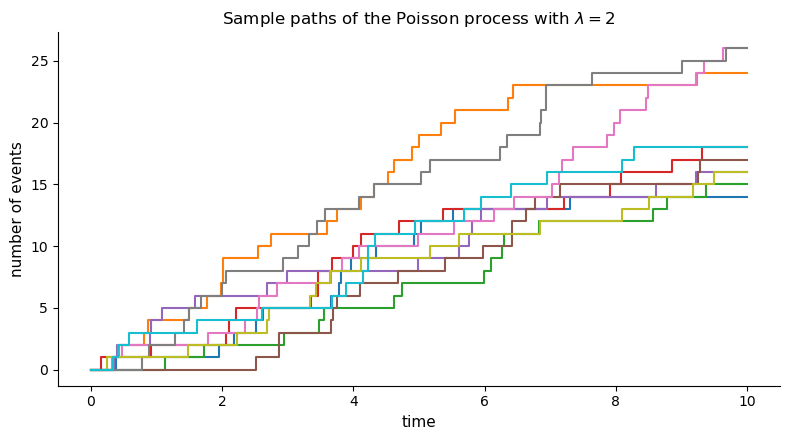

In [36]:
# Time horizon
T_max = 10

# Event rate
lam = 2

# Number of sample paths
n_paths = 10

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=FIGSIZE)

for path in range(n_paths):

    # Simulate event times until the next event would be after T_max
    event_times = []
    current_time = 0

    while current_time <= T_max:
        waiting_time = rng.exponential(1 / lam)
        current_time = current_time + waiting_time

        if current_time <= T_max:
            event_times.append(current_time)

    event_times = np.array(event_times)

    # Build the counting process N(t)
    times = np.concatenate(([0], event_times, [T_max]))
    counts = np.concatenate((
        [0],
        np.arange(1, len(event_times) + 1),
        [len(event_times)]
    ))

    plt.step(times, counts, where="post")

plt.xlabel("time")
plt.ylabel("number of events")
plt.title(f"Sample paths of the Poisson process with $\\lambda={lam}$")
plt.tight_layout()
plt.show()

Each path of $N(t)$ is a step function. It increases by 1 when an event occurs, and stays constant between event times.

### Distribution of $N(t)$

For a fixed time $t$, the random variable $N(t)$ counts how many events have occurred up to time $t$. Although time is continuous, $N(t)$ only takes integer values. For a Poisson process with rate $\lambda$,

$$
N(t) \sim \mathrm{Po}(\lambda t).
$$

More generally, for $0 \leq s \leq t$,

$$
N(t)-N(s) \sim \mathrm{Po}(\lambda(t-s)).
$$

Counts over disjoint time intervals are independent.

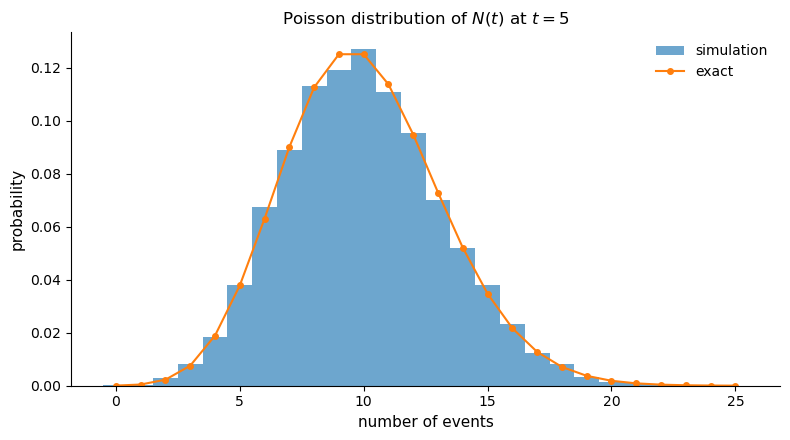

In [20]:
# Fixed time
t = 5

# Event rate
lam = 2

# Number of repeated experiments
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Simulate many values of N(t)
N_values = rng.poisson(lam * t, size=N)

# Values to show
max_k = 25
k_values = np.arange(0, max_k + 1)

# Exact Poisson probabilities
p_exact = poisson.pmf(k_values, lam * t)

plt.figure(figsize=FIGSIZE)

plt.hist(
    N_values,
    bins=np.arange(-0.5, max_k + 1.5, 1),
    density=True,
    alpha=HIST_ALPHA,
    label="simulation"
)

plt.plot(k_values, p_exact, "o-", label="exact")

plt.xlabel("number of events")
plt.ylabel("probability")
plt.title(f"Poisson distribution of $N(t)$ at $t={t}$")
plt.legend()
plt.tight_layout()
plt.show()

The histogram is based on many independent simulations of $N(t)$ at the fixed time $t$. The points show the Poisson probabilities with mean $\lambda t$. The plot shows a distribution at one fixed time, not a sample path.

### Task: phone calls

Suppose calls arrive at a phone line according to a Poisson process with rate

$$
\lambda = 3
$$

calls per hour. 

Use the Poisson distribution of $N(t)$ to find the probability of no calls in half an hour, the probability of exactly one call in half an hour, and the expected number of calls in half an hour.

In [21]:
# Use the Poisson distribution with mean lambda * t.
# Compute the probabilities requested above.

### Example solution

For half an hour, the mean number of calls is $\lambda t=3\cdot 0.5=1.5$.

In [22]:
# Call rate: 3 calls per hour
lam = 3

# Time interval: half an hour
t = 0.5

# Probability of no calls
p_no_call = poisson.pmf(0, lam * t)

# Probability of exactly one call
p_one_call = poisson.pmf(1, lam * t)

# Expected number of calls
expected_calls = lam * t

print("P(no calls in half an hour) =", p_no_call)
print("P(exactly one call in half an hour) =", p_one_call)
print("Expected number of calls =", expected_calls)

P(no calls in half an hour) = 0.22313016014842982
P(exactly one call in half an hour) = 0.33469524022264474
Expected number of calls = 1.5
